<a href="https://colab.research.google.com/github/littlePanda2/ml-assignments/blob/main/assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 5: Learning Vector Quantization

**Course:** WBCS032-05 Introduction to Machine Learning  
**Student Names:** Sophie Schoerner
**Student Numbers:** s4136594

---

## Assignment Overview

In this assginment, you will implement the LVQ1 algorithm as introduced and discussed in class, using Euclidean distance. Consider (a) LVQ1 with one prototype per class; (b) LVQ1 with two prototypes per class.


You will work with the dataset `lvqdata.csv`, which contains 100 two-dimensional feature vectors. Here, we assume that the first 50 points belong to class 1, the other data points belong to class 2.

## 1. Introduction (1 point)

Describe the goal of this assignment.

**Your answer here:**

Assignment 5 focuses on solving a classification problem using the Learning Vector Quantization (LVQ) algorithm. The goal is to assign class labels to data points based on their feature values. LVQ is a prototype-based supervised learning algorithm that represents each class with one or more prototype vectors and classifies samples based on the nearest prototype.

To evaluate the behavior of the algorithm, several experiments were performed. The LVQ model was trained for multiple epochs while tracking the classification error over time. Learning curves were generated to observe how the error rate changes during training. Furthermore, experiments were conducted with different numbers of prototypes in order to analyze how model complexity affects performance.

The algorithm used in this work is LVQ1, where prototypes are iteratively updated based on their distance to training samples. If a prototype has the same class label as the sample, it is moved closer to the sample, otherwise it is moved away from it. This allows the prototypes to gradually represent the structure of the data.

The experiments were conducted on the labeled dataset lvqdata.csv consisting of two-dimensional feature vectors and the corresponding class labels.

## 2. Methods (3 points)

### 2.1 Explain Learning Vector Quantization (0.5 points)

Explain the algorithm in a general manner.

**Your answer here:**

LVQ is a supervised classification algorithm that represents each class using a small set of prototypes. Each prototype is a vector in the feature space and has a class label.

*During training*, the algorithm updates the prototypes. For each training sample, the closest prototype is found. If the prototype has the same label as the sample, it is moved closer to the sample. If the labels differ, the prototype is moved away from the sample. By repeating this process over multiple epochs, the prototypes gradually move to positions that represent the classes well.

*During classification*, a data point is assigned the label of the nearest prototype based on Euclidean distance.

### 2.2 Implementation (2.5 points)

You need to implement the LVQ1 algorithm **yourself**. Both the code quality and correctness will be graded.

*__Note:__* **Do not change the cell labels! Themis will use them to automatically grade your submission.**

In [75]:
# Load required libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data_file_path = 'lvqdata.csv'

eta = 0.002  # the learning rate
t_max = 100  # the maximum number of epochs

In [76]:
# Read input data

df = pd.read_csv(data_file_path, header=None)
data = np.array(df)

# the first 50 data samples belong to class 1 while the others belong to class 2
labels = np.array([1] * 50 + [2] * 50)

#### LVQ1 Steps

Implement the following steps:

1. **Initialize K prototypes per class, e.g., by random selection of data points**

2. **Repeat for epochs $t = 1$ to $t_{max}$:**

      *   In each epoch, present all of the dataset in a randomized order (every example is presented exactly once, the order of examples is different in every epoch). Take care that also the training labels are permuted in the very same way.

      *   perform an epoch of training using all of the P examples. At every individual step present a single example to the system, evaluate the distances from all prototypes and update the winning prototype

      *   After each epoch, compute the predicted labels of the data samples and determine the number E of misclassified training examples, i.e. the "training error".

In [77]:
def classification_label_and_error(data, labels, prototypes, prototype_labels):
    '''
    Compute the predicted labels of the data samples and the number of misclassified samples

    Args:
        data (ndarray): Data points.
        labels (ndarray): labels of individual data points
        prototypes (ndarray): The prototypes
        prototype_labels (ndarray): the labels of the prototypes

    Returns:
        predicted_labels (list): the predicted labels of the data points
        error (int): the number of misclassified samples
    '''

    predicted_labels = []
    errors = 0

    # Iterate through every data point (x) and its true class label (true_label)
    for x, true_label in zip(data, labels):
      distances = np.linalg.norm(prototypes - x, axis=1)
      winner = np.argmin(distances) # np.argmin gives the index of the closest prototype to the given data point
      predicted_label = prototype_labels[winner]
      predicted_labels.append(predicted_label)

      # Compare prediction to true label; increment error counter if they differ
      if predicted_label != true_label:
        errors += 1

    return np.array(predicted_labels), errors

In [78]:
def learning_vector_quantization(data, labels, num_prototypes, learning_rate, max_epoch):
    '''
    Supervised learning vector quantization (LVQ1)

    Args:
        data (ndarray): Data points.
        labels (ndarray): labels of the data points
        num_prototypes (int): The number of prototypes per class
        learning_rate (float): The learning rate
        max_epoch (int): The maximum number of epochs

    Returns:
        prototype_trace (ndarray): the trace of the prototypes over all epochs
        predicted_labels (ndarray): the predicted labels of the data points
        Num_misclassification (ndarray): the number of misclassified samples in each epoch
    '''

    # Initialize containers for prototype coordinates and their class labels
    prototypes = []
    prototype_labels = []

    classes = np.unique(labels)

    # randomly select initial prototypes from existing data points per class
    for c in classes:
        class_data = data[labels == c]
        idx = np.random.choice(len(class_data), num_prototypes, replace=False)

        for i in idx:
            prototypes.append(class_data[i])
            prototype_labels.append(c)

    prototypes = np.array(prototypes)
    prototype_labels = np.array(prototype_labels)

    prototype_trace = [prototypes.copy()] # stores entire history of prototype position
    errors_per_epoch = [] # record error performance per epoch

    for epoch in range(max_epoch):
        # shuffle data indices
        indices = np.random.permutation(len(data))

        for i in indices:
            x = data[i]
            label = labels[i]

            # find index of the nearest prototype (winner)
            distances = np.linalg.norm(prototypes - x, axis=1)
            winner = np.argmin(distances)

            # Update winning prototype: move closer if label matches, move away if incorrect
            if prototype_labels[winner] == label:
                prototypes[winner] += learning_rate * (x - prototypes[winner])
            else:
                prototypes[winner] -= learning_rate * (x - prototypes[winner])

        # record prototype positions and calculate error rate after this epoche
        prototype_trace.append(prototypes.copy())

        predicted_labels, errors = classification_label_and_error(data, labels, prototypes, prototype_labels)

        errors_per_epoch.append(errors)

    return np.array(prototype_trace), predicted_labels, np.array(errors_per_epoch)

## 3. Experimental Results (4 points)

### 3.1 Learning curves

*__Note:__* This section **is graded** by Themis.

Implement the function below in order to generate plots of the error rate $E/P$ as a function of the number of epochs (learning curve). Include learning curve figures for both $K = 1$ and $K = 2$ prototypes per class. Use a learning rate of $\eta = 0.002$ and $t_{max} = 100$ epochs.

In [79]:
def plot_error_rate(data, labels, num_prototypes, learning_rate, max_epoch):
    """
    Plot the error rate (E/P) as a function of the number of epochs.

    Args:
        data (ndarray): Data points.
        labels (ndarray): Labels of the data points.
        num_prototypes (int): Number of prototypes per class.
        learning_rate (float): The learning rate.
        max_epoch (int): Maximum number of epochs.
    """
    # Execute the LVQ algorithm; we only need the error history
    _, _, errors = learning_vector_quantization(data, labels, num_prototypes, learning_rate, max_epoch)

    error_rate = np.array(errors) / len(data)

    plt.figure()
    plt.plot(error_rate)
    plt.xlabel("Epoch")
    plt.ylabel("The error rate in %")
    plt.title(f"Learning curve")
    plt.show()

### 3.2 Classification results

*__Note:__* This section **is graded** by Themis.

Implement the function below to plot the data with LVQ1 predicted labels in the two-dimensional feature space for case (a) and (b) at the end of the training process; also mark the prototype positions. Each figure must include labeled axes and an appropriate title.

In [80]:
def plot_trajectory(data, labels, num_prototypes, learning_rate, max_epoch):
    """
    Plot the final classification result and prototype positions.

    Args:
        data (ndarray): Data points.
        labels (ndarray): Labels of the data points.
        num_prototypes (int): Number of prototypes per class.
        learning_rate (float): The learning rate.
        max_epoch (int): Maximum number of epochs.
    """

    # Execute the LVQ algorithm; we need the final prototype positions and predicted classifications
    prototype_trace, predicted_labels, _ = learning_vector_quantization(data, labels, num_prototypes, learning_rate, max_epoch)

    # plot data points color-coded by the class the model assigned to them
    for c in np.unique(predicted_labels):
        mask = predicted_labels == c
        color = 'red' if c == 1 else 'blue'
        plt.scatter(
            data[mask, 0],
            data[mask, 1],
            color=color
        )

    # Get the final prototypes from the trace
    final_prototypes = prototype_trace[-1]

    # plot each prototype as a star to identify the cluster centers
    for i in range(len(final_prototypes)):
        p_color = 'red' if i < num_prototypes else 'blue'
        plt.scatter(
            final_prototypes[i, 0],
            final_prototypes[i, 1],
            color=p_color,
            marker='*',
            s=200
        )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"Trajectory Of Prototypes")
    plt.show()

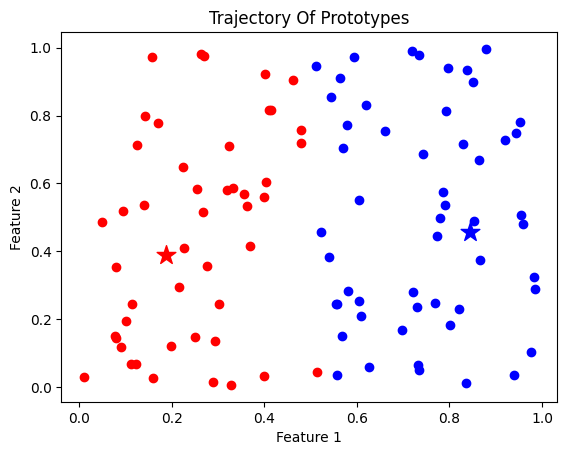

In [81]:
plot_trajectory(data, labels, 1, 0.002, 100)


## 4. Discussion (2 points)

Experiment with different values for $\eta$ and discuss your observations on the obtained results, in particular with respect to the role of the learning rate, addressing the following questions:

- How does the final value of the cost function change with $\eta$?
- What happens if $\eta$ is too large or too small?
- What difference is there between using 1 or 2 prototypes per class?

**Your answer here:**

**How does the final value of the cost function change with $\eta$?**

The learning rate $\eta$ controls the step size of each prototype update. I tried four different learning rates ($\eta$=0.0002, 0.002, 0.02, 0.2) over 100 epochs with K=1.

Stable convergence ($\eta$=0.002): The cost function showed a steady decline throughout the 100 epochs, and the prototypes settled into their final positions.

More aggressive learning ($\eta$=0.02): The error dropped more rapidly in the initial phase compared to the 0.002 setup. Then the error curve remained a bit jittery.

Instability ($\eta$=0.2): At this high rate, the system became completely unstable. The cost function showed erratic, super jittery fluctuations with no meaningful improvement. The prototypes consistently overcompensated and missed their final positions.

Stagnation ($\eta$=0.0002): With very small $\eta$, the decrease in error was noticable, but small. The learning process was too slow to achieve any significant optimization within the 100-epochs.

Conclusion: The learning rate $\eta$ controls the step size of each prototype update. Ultimately, the choice of $\eta$ is a critical trade-off between speed and stability. With a stable, small $\eta$ (like 0.002 used in the implementation), the cost function (training error) generally shows a steady decline over 100 epochs. If $\eta$ were increased, the cost function might reach a lower error faster, but the risk is failing to settle, as the prototypes might "jump" over the optimal positions.

**What happens if $\eta$ is too large or too small?**

Too large: If $\eta$ is too big, we risk instability. The prototypes may oscillate because the updates are too much, causing them to move past the ideal cluster centers in the feature space. This results in a jittery learning curve that does not minimize the classification error well.

Too small: If $\eta$ is too small, the convergence is extremely slow. The prototypes may not move enough within the 100-epoch limit to effectively partition the space, resulting in a higher final training error because the model has not had enough "time" to learn the structure of the data.

**What difference is there between using 1 or 2 prototypes per class?**

1 Prototype per class: This represents the data with a single central point per class. It creates a simple, linear decision boundary (Voronoi boundary). This is efficient but limited in expressive power. If the data within a class is distributed in *multiple* distinct clusters, a single prototype will likely be put in the geometric center of those clusters, which may lead to higher misclassification rates.

2 Prototypes per class: By using two prototypes, the model gains the flexibility to represent more complex data distributions. Each class can now be modeled by two separate centers, allowing the decision boundary to better conform to the data. This typically results in a lower training error compared to the K=1 case.

## Contribution

State your individual contribution.

**Your answer here:**

Sophie: 1., 2., 3., 4.